In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

In [4]:
path = "../data/raw/"

orders    = pd.read_csv(path + "olist_orders_dataset.csv")
items     = pd.read_csv(path + "olist_order_items_dataset.csv")
payments  = pd.read_csv(path + "olist_order_payments_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
products  = pd.read_csv(path + "olist_products_dataset.csv")
sellers   = pd.read_csv(path + "olist_sellers_dataset.csv")
reviews   = pd.read_csv(path + "olist_order_reviews_dataset.csv")
mql   = pd.read_csv(path + "olist_marketing_qualified_leads_dataset.csv")
deals = pd.read_csv(path + "olist_closed_deals_dataset.csv")

In [5]:
datasets = {
    'orders': orders, 'items': items, 'payments': payments,
    'customers': customers, 'products': products, 'sellers': sellers,
    'reviews': reviews, 'mql': mql, 'deals': deals
}

for name, df in datasets.items():
    print(f"{name:12} → {df.shape[0]:>6} rows | {df.shape[1]:>2} cols")

orders       →  99441 rows |  8 cols
items        → 112650 rows |  7 cols
payments     → 103886 rows |  5 cols
customers    →  99441 rows |  5 cols
products     →  32951 rows |  9 cols
sellers      →   3095 rows |  4 cols
reviews      →  99224 rows |  7 cols
mql          →   8000 rows |  4 cols
deals        →    842 rows | 14 cols


In [6]:
# Orders overview
print("=== ORDERS ===")
print(orders.columns.tolist())
print(orders['order_status'].value_counts())
print(orders.isnull().sum())

=== ORDERS ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [7]:
# MQL - our channel data
print("=== MQL CHANNELS ===")
print(mql.columns.tolist())
print(mql['origin'].value_counts())

=== MQL CHANNELS ===
['mql_id', 'first_contact_date', 'landing_page_id', 'origin']
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64


In [8]:
# Deals - conversion data
print("=== DEALS ===")
print(deals.columns.tolist())
print(deals.head(3))

=== DEALS ===
['mql_id', 'seller_id', 'sdr_id', 'sr_id', 'won_date', 'business_segment', 'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin', 'average_stock', 'business_type', 'declared_product_catalog_size', 'declared_monthly_revenue']
                             mql_id                         seller_id  \
0  5420aad7fec3549a85876ba1c529bd84  2c43fb513632d29b3b58df74816f1b06   
1  a555fb36b9368110ede0f043dfc3b9a0  bbb7d7893a450660432ea6652310ebb7   
2  327174d3648a2d047e8940d7d15204ca  612170e34b97004b3ba37eae81836b4c   

                             sdr_id                             sr_id  \
0  a8387c01a09e99ce014107505b92388c  4ef15afb4b2723d8f3d81e51ec7afefe   
1  09285259593c61296eef10c734121d5b  d3d1e91a157ea7f90548eef82f1955e3   
2  b90f87164b5f8c2cfa5c8572834dbe3f  6565aa9ce3178a5caf6171827af3a9ba   

              won_date business_segment      lead_type lead_behaviour_profile  \
0  2018-02-26 19:58:54              pet  online_medium                    cat   
1 

In [9]:
channel_df = mql.merge(deals, on='mql_id', how='left')

channel_df['converted'] = channel_df['seller_id'].notna().astype(int)

conv = channel_df.groupby('origin').agg(
    total_leads = ('mql_id', 'count'),
    converted   = ('converted', 'sum')
).reset_index()

conv['conversion_rate_%'] = (conv['converted'] / conv['total_leads'] * 100).round(2)
conv = conv.sort_values('conversion_rate_%', ascending=False)
print(conv)

              origin  total_leads  converted  conversion_rate_%
9            unknown         1099        179              16.29
6        paid_search         1586        195              12.30
3     organic_search         2296        271              11.80
0     direct_traffic          499         56              11.22
7           referral          284         24               8.45
8             social         1350         75               5.56
1            display          118          6               5.08
5  other_publicities           65          3               4.62
2              email          493         15               3.04
4              other          150          4               2.67


In [11]:
import os
os.makedirs('../reports', exist_ok=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_25724\782727308.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean_conv.sort_values('conversion_rate_%', ascending=False),


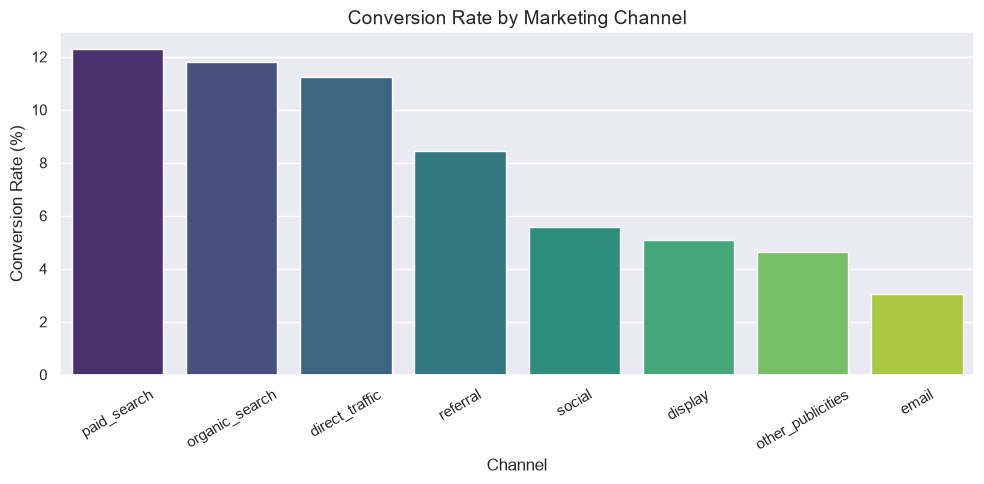

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

clean_conv = conv[~conv['origin'].isin(['unknown', 'other'])].copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=clean_conv.sort_values('conversion_rate_%', ascending=False),
            x='origin', y='conversion_rate_%', palette='viridis')
plt.title('Conversion Rate by Marketing Channel', fontsize=14)
plt.xlabel('Channel')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/01_conversion_rate_by_channel.png', dpi=150)
plt.show()

In [13]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Date Range:")
print(f"From : {orders['order_purchase_timestamp'].min()}")
print(f"To   : {orders['order_purchase_timestamp'].max()}")
print(f"\nDelivered orders: {(orders['order_status'] == 'delivered').sum()}")
print(f"Cancelled orders: {(orders['order_status'] == 'canceled').sum()}")

Date Range:
From : 2016-09-04 21:15:19
To   : 2018-10-17 17:30:18

Delivered orders: 96478
Cancelled orders: 625


In [14]:
print("=== PAYMENT STATS ===")
print(payments['payment_value'].describe().round(2))
print(f"\nTotal Revenue : R$ {payments['payment_value'].sum():,.2f}")
print(f"Avg Order Value: R$ {payments['payment_value'].mean():,.2f}")

=== PAYMENT STATS ===
count    103886.00
mean        154.10
std         217.49
min           0.00
25%          56.79
50%         100.00
75%         171.84
max       13664.08
Name: payment_value, dtype: float64

Total Revenue : R$ 16,008,872.12
Avg Order Value: R$ 154.10
